# 🚕 Taxi Fare Prediction: ML for Transport Pricing & Regulation

**Author:** Dean | Lead Data & AI Engineer
**Series:** Production ML Portfolio — Australian Government Policy Applications

## Government Context
- **State Transport Regulators** — Taxi/rideshare fare regulation
- **ACCC** — Surge pricing fairness, rideshare competition
- **ABS** — CPI transport component, gig economy statistics
- **Fair Work** — Gig worker conditions, contractor classification

Dataset: seaborn built-in taxis — NO dataset needed.

---

## 1. Data Loading

In [1]:
import warnings,time,numpy as np,pandas as pd,matplotlib.pyplot as plt,seaborn as sns
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
warnings.filterwarnings('ignore');plt.style.use('seaborn-v0_8-whitegrid')
df=sns.load_dataset('taxis').dropna().reset_index(drop=True)
print(f"Loaded: {df.shape[0]:,} x {df.shape[1]}")
for i,col in enumerate(df.columns):
    print(f"  {i}. {col:18s} | {str(df[col].dtype):12s} | uniq={df[col].nunique()}")
df.head()

Loaded: 6,341 x 14
  0. pickup             | datetime64[ns] | uniq=6322
  1. dropoff            | datetime64[ns] | uniq=6333
  2. passengers         | int64        | uniq=7
  3. distance           | float64      | uniq=1064
  4. fare               | float64      | uniq=206
  5. tip                | float64      | uniq=481
  6. tolls              | float64      | uniq=14
  7. total              | float64      | uniq=877
  8. color              | object       | uniq=2
  9. payment            | object       | uniq=2
  10. pickup_zone        | object       | uniq=194
  11. dropoff_zone       | object       | uniq=203
  12. pickup_borough     | object       | uniq=4
  13. dropoff_borough    | object       | uniq=5


,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


## 2. Target

Target: 'total'
count    6341.000000
mean       18.310263
std        12.950365
min         1.300000
25%        10.800000
50%        14.160000
75%        20.300000
max       174.820000
Name: total, dtype: float64


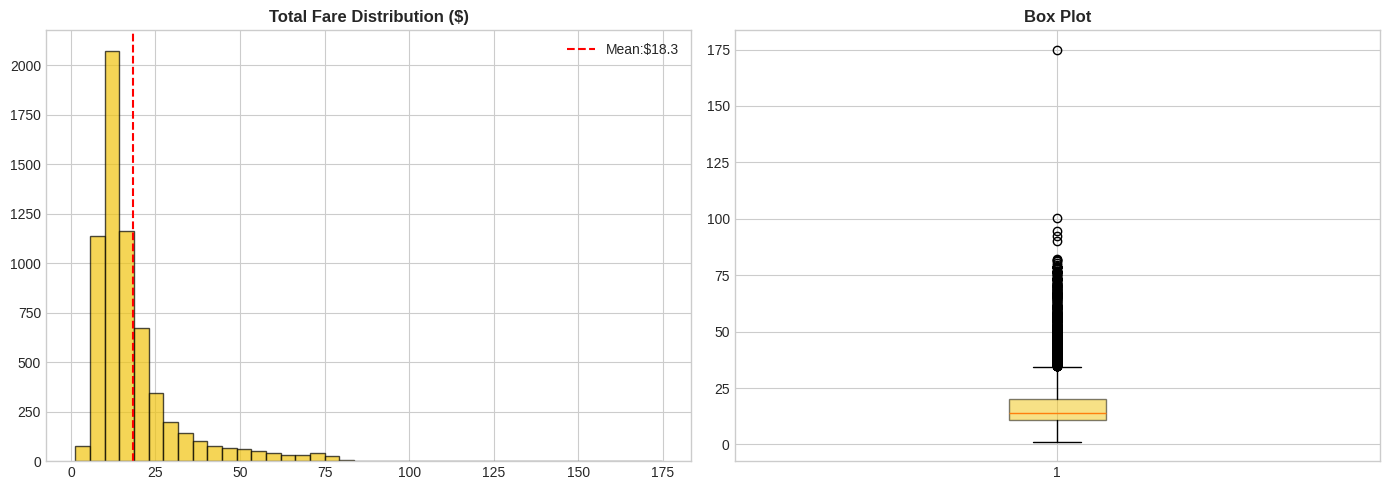

AU: Taxi/rideshare market ~$7B. State regulators set fare structures.


In [2]:
tc='total'
print(f"Target: '{tc}'");print(df[tc].describe())
fig,axes=plt.subplots(1,2,figsize=(14,5))
axes[0].hist(df[tc],bins=40,color='#f1c40f',edgecolor='black',alpha=0.7)
axes[0].set_title('Total Fare Distribution ($)',fontweight='bold')
axes[0].axvline(df[tc].mean(),color='red',ls='--',label=f'Mean:${df[tc].mean():.1f}')
axes[0].legend()
axes[1].boxplot(df[tc],patch_artist=True,boxprops=dict(facecolor='#f1c40f',alpha=0.5))
axes[1].set_title('Box Plot',fontweight='bold')
plt.tight_layout();plt.savefig('target.png',dpi=150);plt.show()
print("AU: Taxi/rideshare market ~$7B. State regulators set fare structures.")

## 3. EDA & Preprocessing

  Encoded 'color': 2
  Encoded 'payment': 2
Numeric: ['passengers', 'distance', 'fare', 'tip', 'tolls', 'color', 'payment']


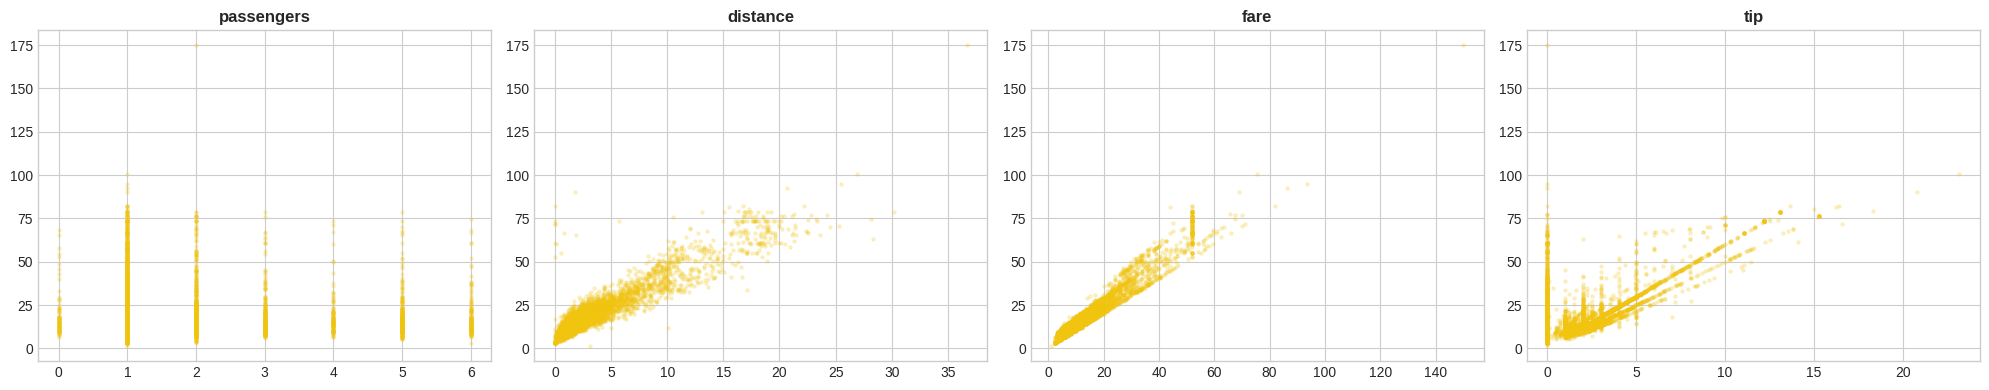

In [3]:
# Drop datetime and pickup/dropoff (too many unique)
drop=['pickup','dropoff','pickup_zone','dropoff_zone','pickup_borough','dropoff_borough']
df2=df.drop(columns=[c2 for c2 in drop if c2 in df.columns],errors='ignore')
le_d={}
for col in df2.select_dtypes(include=['object','category','datetime64[ns]']).columns:
    if col!=tc:
        le=LabelEncoder();df2[col]=le.fit_transform(df2[col].astype(str));le_d[col]=le
        print(f"  Encoded '{col}': {len(le.classes_)}")
nums=[c2 for c2 in df2.select_dtypes(include=[np.number]).columns if c2!=tc]
print(f"Numeric: {nums}")
if len(nums)>1:
    fig,axes=plt.subplots(1,min(len(nums),4),figsize=(5*min(len(nums),4),4))
    if not isinstance(axes,np.ndarray): axes=[axes]
    for i,col in enumerate(nums[:4]):
        axes[i].scatter(df2[col],df2[tc],alpha=0.2,s=5,color='#f1c40f')
        axes[i].set_title(col,fontweight='bold')
    plt.tight_layout();plt.savefig('scatter.png',dpi=150);plt.show()

## 4-5. Training

In [4]:
X=df2[nums].copy();y=df2[tc].values;X=X.fillna(X.median())
# Remove target-leaking fare column if present
leak=[c2 for c2 in X.columns if c2 in ['fare','tip','tolls']]
if leak: X=X.drop(columns=leak);print(f"Dropped leakage: {leak}")
try:
    from xgboost import XGBRegressor
except: XGBRegressor=None
try:
    from lightgbm import LGBMRegressor
except: LGBMRegressor=None
models={'Ridge':Ridge(alpha=1.0),'RF':RandomForestRegressor(n_estimators=100,random_state=42,n_jobs=-1)}
if XGBRegressor: models['XGB']=XGBRegressor(n_estimators=100,random_state=42,verbosity=0,n_jobs=-1)
if LGBMRegressor: models['LGBM']=LGBMRegressor(n_estimators=100,random_state=42,verbose=-1,n_jobs=-1,force_col_wise=True)
kf=KFold(3,shuffle=True,random_state=42);Xa=X.values;results={}
for mn,mod in models.items():
    print(f"\n{'='*50}\n{mn}\n{'='*50}")
    fr,fm,f2=[],[],[];fp=np.zeros(len(y));t0=time.time()
    for fi,(ti,vi) in enumerate(kf.split(Xa)):
        m2=type(mod)(**mod.get_params());m2.fit(Xa[ti],y[ti]);yp=m2.predict(Xa[vi]);fp[vi]=yp
        r=np.sqrt(mean_squared_error(y[vi],yp));m3=mean_absolute_error(y[vi],yp);s=r2_score(y[vi],yp)
        fr.append(r);fm.append(m3);f2.append(s);print(f"  Fold{fi+1}: RMSE={r:.2f} MAE={m3:.2f} R2={s:.4f}")
    el=time.time()-t0;results[mn]={'rmse':np.mean(fr),'mae':np.mean(fm),'r2':np.mean(f2),'time':el,'preds':fp}
    print(f"  AVG: RMSE={np.mean(fr):.2f} R2={np.mean(f2):.4f}")

Dropped leakage: ['fare', 'tip', 'tolls']

Ridge
  Fold1: RMSE=4.78 MAE=2.53 R2=0.8641
  Fold2: RMSE=4.32 MAE=2.44 R2=0.8850
  Fold3: RMSE=4.14 MAE=2.50 R2=0.9008
  AVG: RMSE=4.41 R2=0.8833

RF
  Fold1: RMSE=4.80 MAE=2.66 R2=0.8629
  Fold2: RMSE=4.74 MAE=2.60 R2=0.8615
  Fold3: RMSE=4.73 MAE=2.60 R2=0.8704
  AVG: RMSE=4.76 R2=0.8649

XGB
  Fold1: RMSE=4.68 MAE=2.50 R2=0.8699
  Fold2: RMSE=4.81 MAE=2.49 R2=0.8575
  Fold3: RMSE=4.65 MAE=2.45 R2=0.8745
  AVG: RMSE=4.71 R2=0.8673

LGBM
  Fold1: RMSE=4.53 MAE=2.43 R2=0.8779
  Fold2: RMSE=4.32 MAE=2.39 R2=0.8851
  Fold3: RMSE=4.37 MAE=2.33 R2=0.8890
  AVG: RMSE=4.41 R2=0.8840


## 6. Comparison & Deployment

COMPARISON
Model RMSE  MAE     R2
 LGBM 4.41 2.38 0.8840
Ridge 4.41 2.49 0.8833
  XGB 4.71 2.48 0.8673
   RF 4.76 2.62 0.8649

Best: LGBM


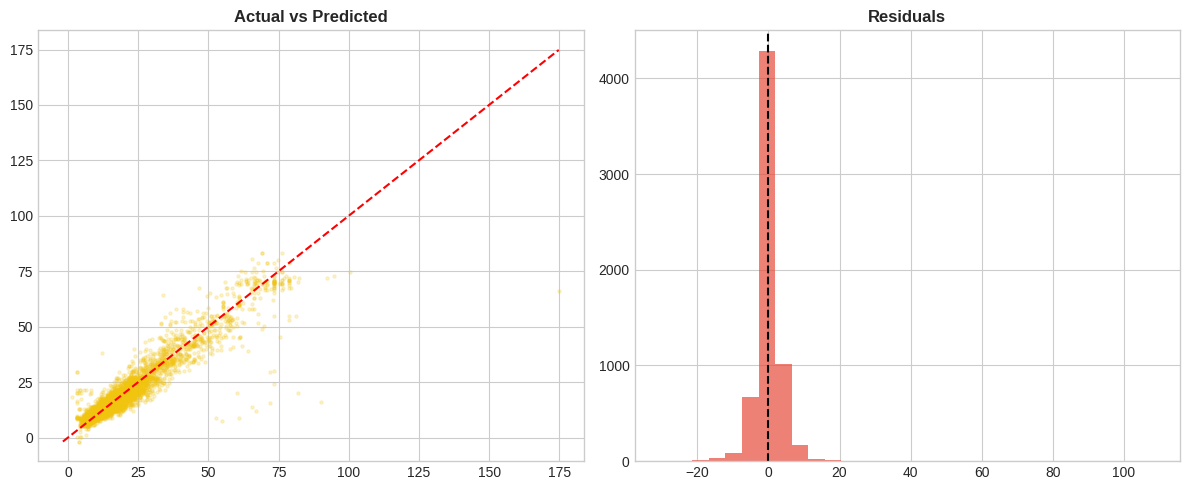


DEPLOYMENT READINESS
  Model: LGBM  R2: 0.8840  MAE: $2.38
  Feats: 4  Rows: 6,341
  Architecture: Rideshare API data -> Fabric -> fare regulation analytics


In [5]:
rows=[{'Model':k,'RMSE':f"{v['rmse']:.2f}",'MAE':f"{v['mae']:.2f}",'R2':f"{v['r2']:.4f}",'s':v['r2']} for k,v in results.items()]
sdf=pd.DataFrame(rows).sort_values('s',ascending=False);best=sdf.iloc[0]['Model']
print("COMPARISON");print("="*60);print(sdf[['Model','RMSE','MAE','R2']].to_string(index=False));print(f"\nBest: {best}")
bp=results[best]['preds'];res=y-bp
fig,axes=plt.subplots(1,2,figsize=(12,5))
axes[0].scatter(y,bp,alpha=0.2,s=5,color='#f1c40f');lm=[min(y.min(),bp.min()),max(y.max(),bp.max())]
axes[0].plot(lm,lm,'r--');axes[0].set_title('Actual vs Predicted',fontweight='bold')
axes[1].hist(res,bins=30,color='#e74c3c',alpha=0.7);axes[1].axvline(0,color='k',ls='--');axes[1].set_title('Residuals',fontweight='bold')
plt.tight_layout();plt.savefig('resid.png',dpi=150);plt.show()
br=results[best]
print("\n"+"="*60);print("DEPLOYMENT READINESS");print("="*60)
print(f"  Model: {best}  R2: {br['r2']:.4f}  MAE: ${br['mae']:.2f}")
print(f"  Feats: {X.shape[1]}  Rows: {len(y):,}")
print("  Architecture: Rideshare API data -> Fabric -> fare regulation analytics")